In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ot
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [2]:
from epot import (
    display_gmm,
    GaussianMixture,
    gaussian_cost_matrix,
    gaussian_W,
    entropic_partial_ot,
)

/home/yukimura/EPOT-pMGW/src/epot/__init__.py:901: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=norm)


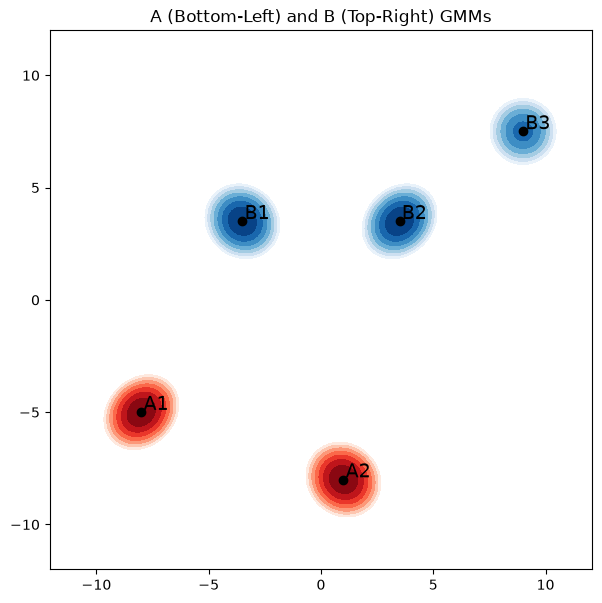

In [3]:
# ---------------------------------------
# 1. GMM A（左下：2成分）
# ---------------------------------------
alpha_A = np.array([0.5, 0.5])

means_A = np.array(
    [
        [-8.0, -5.0],  # A1（左下）
        [1.0, -8.0],  # A2（左下・やや右）
    ]
)

covs_A = 0.2 * np.array(
    [
        [[1, 0.2], [0.2, 1]],
        [[1, -0.1], [-0.1, 1]],
    ]
)

gmm_A = [2, alpha_A, means_A, covs_A]

# ---------------------------------------
# 2. GMM B（右上：2成分 + ノイズ1成分）
# ---------------------------------------
alpha_B = np.array([0.45, 0.45, 0.1])

means_B = np.array(
    [
        [-3.5, 3.5],  # B1（右上）
        [3.5, 3.5],  # B2（右上・やや右）
        [9.0, 7.5],  # B3（ノイズ：さらに右）
    ]
)

covs_B = 0.2 * np.array(
    [
        [[1, -0.1], [-0.1, 1]],
        [[1, 0.2], [0.2, 1]],
        [[1, 0.0], [0.0, 1]],  # ノイズは等方
    ]
)

gmm_B = [3, alpha_B, means_B, covs_B]

# ---------------------------------------
# 3. 描画
# ---------------------------------------
plt.figure(figsize=(7, 7))

# A（左下）
display_gmm(gmm_A, n=300, ax=-12, bx=12, ay=-12, by=12, cmap="Reds")
for i, (x, y) in enumerate(means_A):
    plt.scatter(x, y, c="black")
    plt.text(x + 0.1, y + 0.1, f"A{i + 1}", color="black", fontsize=14)

# B（右上）
display_gmm(gmm_B, n=300, ax=-12, bx=12, ay=-12, by=12, cmap="Blues")
labels = ["B1", "B2", "B3"]
for i, (x, y) in enumerate(means_B):
    plt.scatter(x, y, c="black")
    plt.text(x + 0.1, y + 0.1, labels[i], color="black", fontsize=14)

plt.title("A (Bottom-Left) and B (Top-Right) GMMs")
plt.axis("equal")
plt.savefig("GMMs.eps", format="eps")
plt.show()

In [4]:
Lambda = 0.3
Gmm_1 = GaussianMixture(alpha_A, means_A, covs_A)
Gmm_2 = GaussianMixture(alpha_B, means_B, covs_B)
C1 = gaussian_cost_matrix(Gmm_1)
C2 = gaussian_cost_matrix(Gmm_2)
M = gaussian_W(Gmm_1, Gmm_2) / np.max(gaussian_W(Gmm_1, Gmm_2))
print("M= ", M)
print("a=", Gmm_1.weights)
print("b=", Gmm_2.weights)

p = Gmm_1.weights
q = Gmm_2.weights
a_ext = np.append(p, 1.0)
b_ext = np.append(q, 1.0)
M = M - 2 * Lambda

n, m = M.shape

M_ext = np.zeros((n + 1, m + 1))
M_ext[:n, :m] = M

res = ot.sinkhorn(
    a_ext,
    b_ext,
    M_ext,
    reg=0.01,
    method="sinkhorn",
    numItermax=1000,
    stopThr=1e-09,
    verbose=False,
    log=False,
    warn=True,
    warmstart=None,
)
res = res[:-1, :-1]
print("p=", p)
print("q=", q)
print("C1=", C1)
print("C2=", C2)
print("res=", res)
print("m=", np.sum(res))

M=  [[0.20776695 0.45928835 1.        ]
 [0.34250109 0.31107875 0.68332001]]
a= [0.5 0.5]
b= [0.45 0.45 0.1 ]
p= [0.5 0.5]
q= [0.45 0.45 0.1 ]
C1= [[4.44089210e-16 9.00090745e+01]
 [9.00090745e+01 0.00000000e+00]]
C2= [[0.00000000e+00 4.90090745e+01 1.72251003e+02]
 [4.90090745e+01 4.44089210e-16 4.62540511e+01]
 [1.72251003e+02 4.62540511e+01 0.00000000e+00]]
res= [[4.49999366e-01 1.64653477e-07 2.36018388e-20]
 [6.33523049e-07 4.49999835e-01 1.33709803e-06]]
m= 0.9000013369014376


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


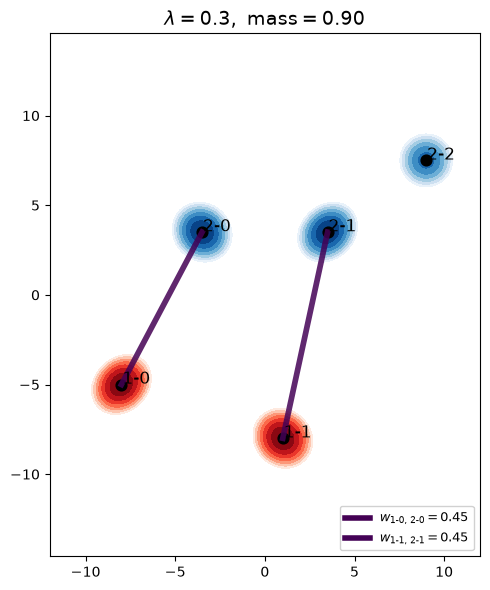

In [5]:
# ----------------------------
# parameters
# ----------------------------
Lambda_list = np.arange(0.3, 0.325, 0.125)

fig, axes = plt.subplots(1, len(Lambda_list), figsize=(5 * len(Lambda_list), 6))

# ★ single Lambda 対策
if len(Lambda_list) == 1:
    axes = [axes]

M = gaussian_W(Gmm_1, Gmm_2)
M = M / np.max(M)

# ============================
# main loop
# ============================
for idx, Lambda in enumerate(Lambda_list):
    # ----------------------------------------
    # 1. entropic partial OT
    # ----------------------------------------
    R = entropic_partial_ot(
        a=Gmm_1.weights,
        b=Gmm_2.weights,
        M=M,
        Lambda=Lambda,
        reg=0.01,
        numItermax=1000,
        stopThr=1e-9,
        remove_dummy=True,
    )

    mass_partial = np.sum(R)

    ax = axes[idx]
    plt.sca(ax)

    # ----------------------------------------
    # 2. draw GMMs
    # ----------------------------------------
    display_gmm(
        [Gmm_1.K, Gmm_1.weights, Gmm_1.comp_mean, Gmm_1.comp_cov],
        n=200,
        ax=-12,
        bx=12,
        ay=-12,
        by=12,
        cmap="Reds",
    )
    display_gmm(
        [Gmm_2.K, Gmm_2.weights, Gmm_2.comp_mean, Gmm_2.comp_cov],
        n=200,
        ax=-12,
        bx=12,
        ay=-12,
        by=12,
        cmap="Blues",
    )

    # ----------------------------------------
    # 3. centers + labels
    # ----------------------------------------
    for i, (x, y) in enumerate(Gmm_1.comp_mean):
        ax.scatter(x, y, c="black", s=60)
        ax.text(x + 0.05, y + 0.05, f"1-{i}", fontsize=12)

    for j, (x, y) in enumerate(Gmm_2.comp_mean):
        ax.scatter(x, y, c="black", s=60)
        ax.text(x + 0.05, y + 0.05, f"2-{j}", fontsize=12)

    # ----------------------------------------
    # 4. collect active couplings
    # ----------------------------------------
    eps = 2.0e-3
    pairs = [(i, j) for i in range(Gmm_1.K) for j in range(Gmm_2.K) if R[i, j] >= eps]

    if len(pairs) == 0:
        ax.set_title(f"Lambda={Lambda}\n(no coupling)", fontsize=13)
        ax.axis("equal")
        continue

    # ----------------------------------------
    # 5. assign colors
    # ----------------------------------------
    cmap = plt.get_cmap("viridis")
    color_dict = {(i, j): cmap(k) for k, (i, j) in enumerate(pairs)}

    # ----------------------------------------
    # 6. draw coupling lines
    # ----------------------------------------
    for i, j in pairs:
        w = R[i, j]
        p1 = Gmm_1.comp_mean[i]
        p2 = Gmm_2.comp_mean[j]

        lw = 0.5 + 8.0 * w

        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            linewidth=lw,
            color=color_dict[(i, j)],
            alpha=0.85,
        )

    # ----------------------------------------
    # 7. legend (lower right)
    # ----------------------------------------
    legend_elements = [
        Line2D(
            [0],
            [0],
            color=color_dict[(i, j)],
            lw=4,
            label=rf"$w_{{1\text{{-}}{i},\,2\text{{-}}{j}}}={R[i, j]:.2f}$",
        )
        for (i, j) in pairs
    ]

    ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.9)

    ax.set_title(
        rf"$\lambda={Lambda},\ \mathrm{{mass}}={mass_partial:.2f}$", fontsize=14
    )
    ax.axis("equal")

# ============================
# finalize
# ============================
plt.tight_layout()
plt.savefig("fig_single_lambda_colored_wlabel.eps", format="eps", bbox_inches="tight")
plt.show()

C1= [[4.44089210e-16 9.00090745e+01]
 [9.00090745e+01 0.00000000e+00]]
C2= [[0.00000000e+00 4.90090745e+01 1.72251003e+02]
 [4.90090745e+01 4.44089210e-16 4.62540511e+01]
 [1.72251003e+02 4.62540511e+01 0.00000000e+00]]
Lambda=0.125, reg=0.01, mass_partial=0.4196
Lambda=0.1875, reg=0.01, mass_partial=0.8892
Lambda=0.25, reg=0.01, mass_partial=0.9000
Lambda=0.3125, reg=0.01, mass_partial=0.9000
Lambda=0.375, reg=0.01, mass_partial=0.9489
Lambda=0.4375, reg=0.01, mass_partial=0.9895
Lambda=0.5, reg=0.01, mass_partial=0.9994
Lambda=0.125, reg=0.11, mass_partial=0.4128
Lambda=0.1875, reg=0.11, mass_partial=0.5433
Lambda=0.25, reg=0.11, mass_partial=0.6641
Lambda=0.3125, reg=0.11, mass_partial=0.7621


/home/yukimura/EPOT-pMGW/.venv/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Lambda=0.375, reg=0.11, mass_partial=0.8339
Lambda=0.4375, reg=0.11, mass_partial=0.8846
Lambda=0.5, reg=0.11, mass_partial=0.9211
Lambda=0.125, reg=0.21000000000000002, mass_partial=0.4402
Lambda=0.1875, reg=0.21000000000000002, mass_partial=0.5113
Lambda=0.25, reg=0.21000000000000002, mass_partial=0.5815
Lambda=0.3125, reg=0.21000000000000002, mass_partial=0.6480


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Lambda=0.375, reg=0.21000000000000002, mass_partial=0.7087
Lambda=0.4375, reg=0.21000000000000002, mass_partial=0.7625
Lambda=0.5, reg=0.21000000000000002, mass_partial=0.8089


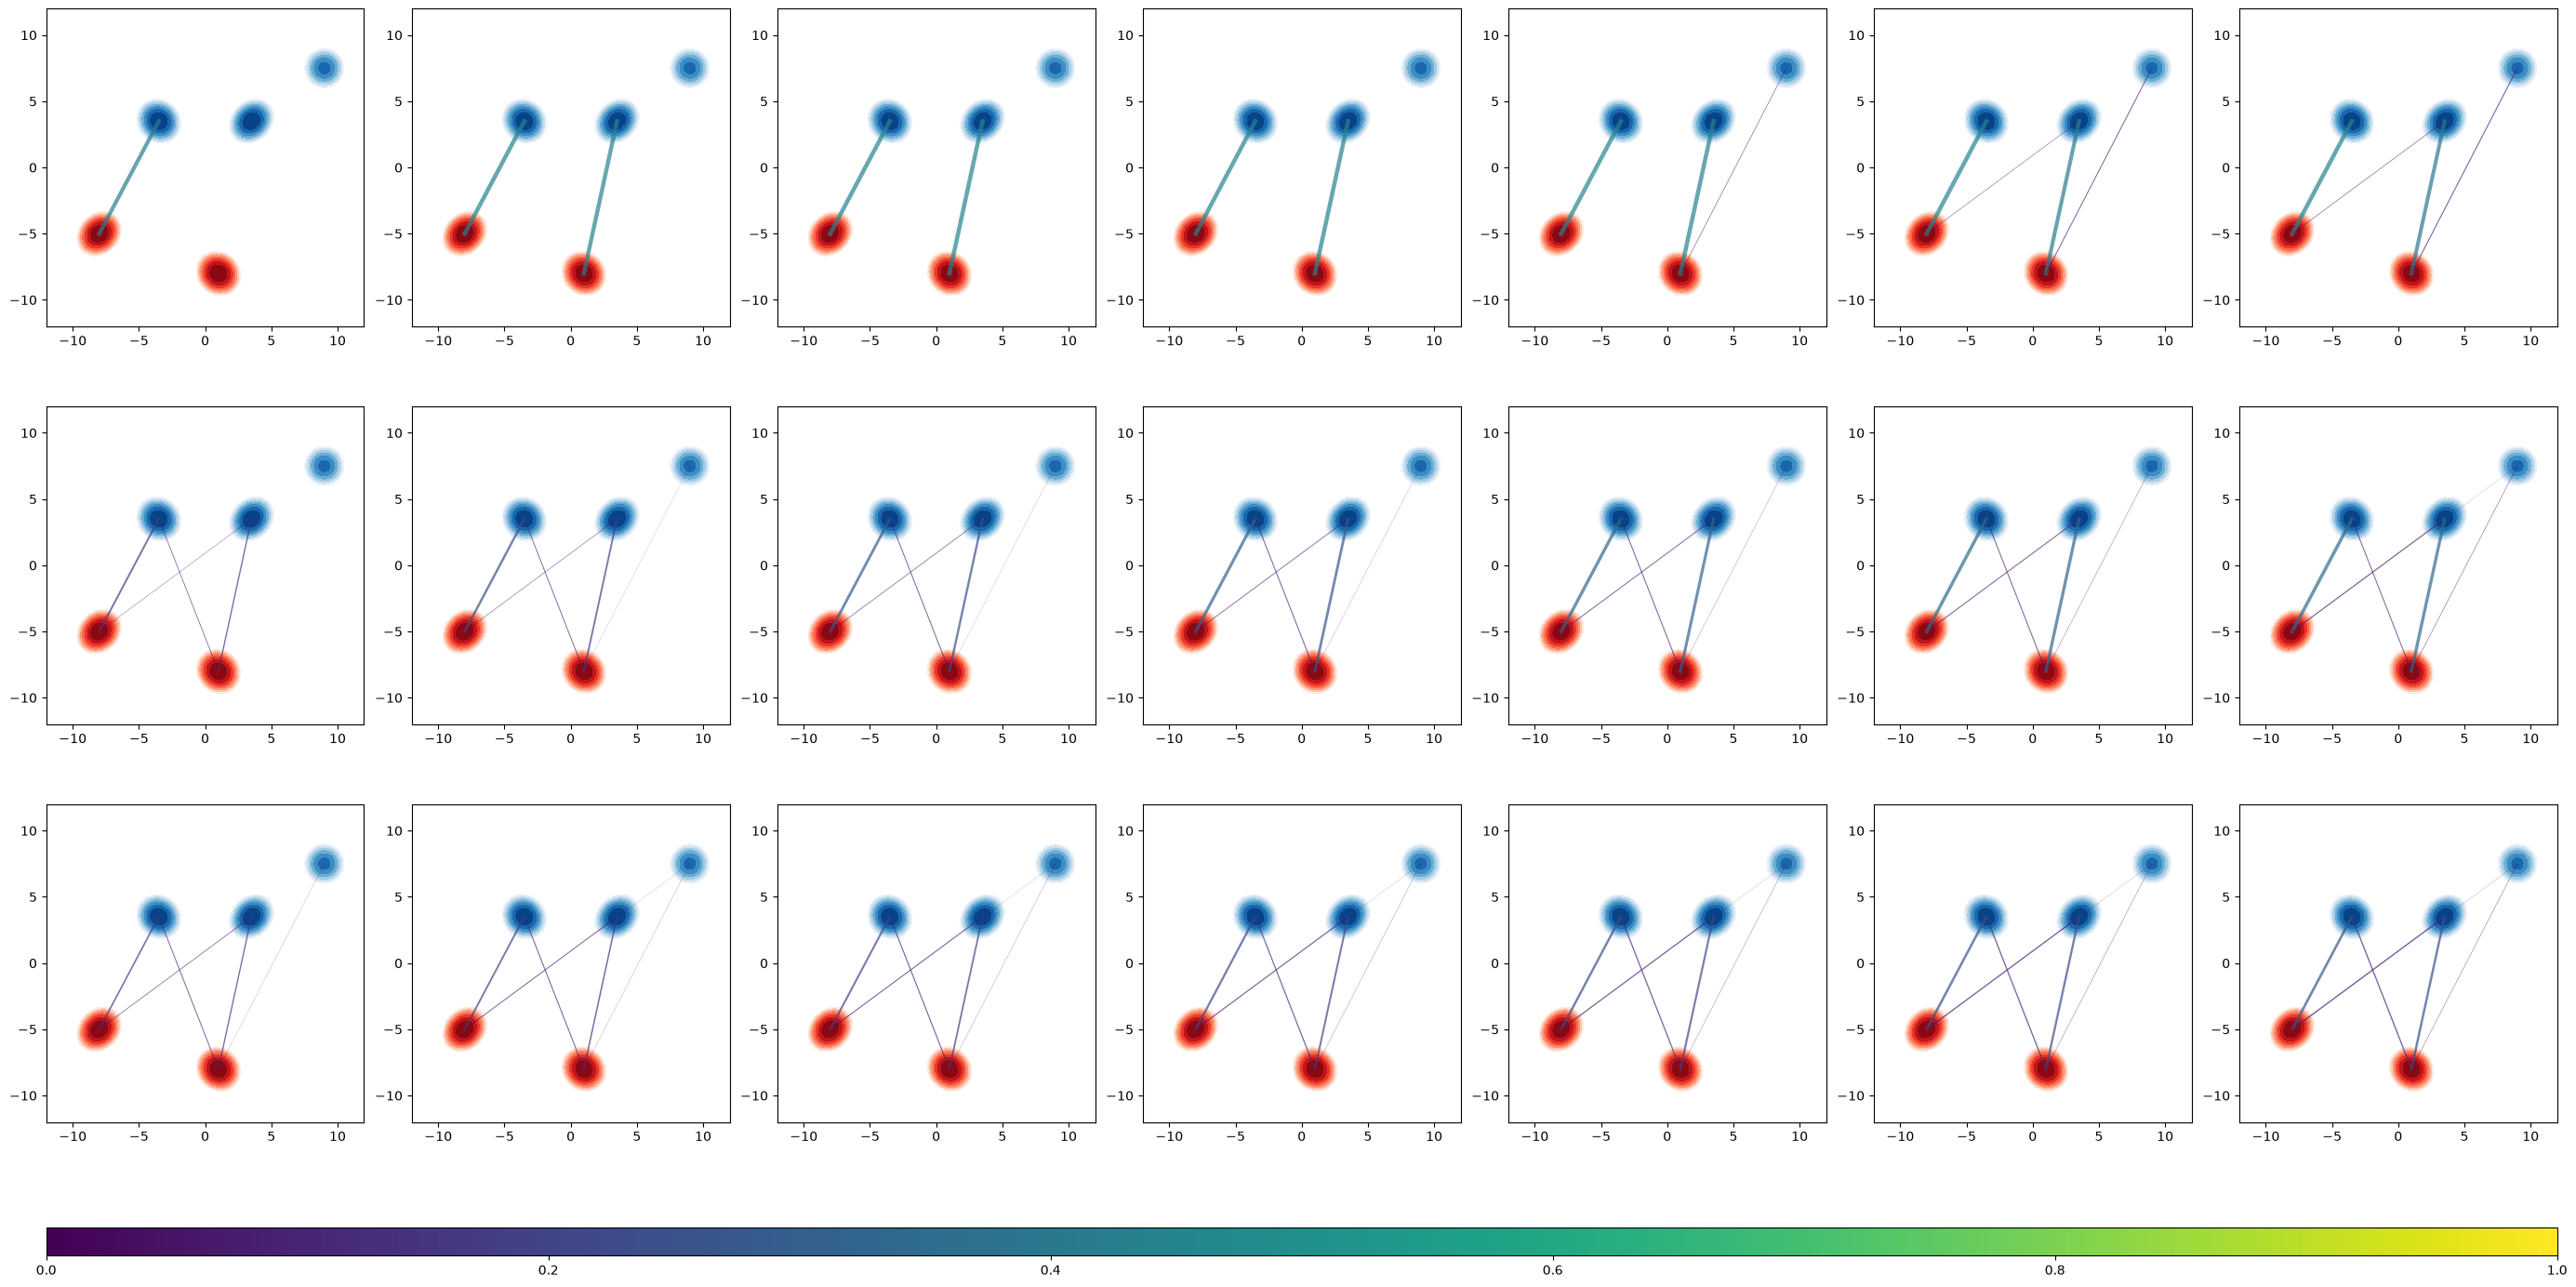

In [6]:
# ----------------------------
# パラメータ
# ----------------------------
Lambda_list = np.arange(0.125, 0.5625, 0.0625)
reg_list = np.arange(0.01, 0.31, 0.1)

print("C1=", C1)
print("C2=", C2)

k = 2 * max(np.max(C1), np.max(C2))
cost1 = C1 / k
cost2 = C2 / k
M = gaussian_W(Gmm_1, Gmm_2)
M = M / np.max(M)

# ----------------------------
# Figure 作成
# ----------------------------
fig, axes = plt.subplots(len(reg_list), len(Lambda_list), figsize=(30, 15))

# ----------------------------
# カラーマップ設定
# ----------------------------
cmap = plt.get_cmap("viridis")
norm = Normalize(vmin=0, vmax=np.max(M))  # R[i,j] の最大値に応じてスケーリング

# ----------------------------
# メインループ
# ----------------------------
for row, reg in enumerate(reg_list):
    for col, Lambda in enumerate(Lambda_list):
        ax = axes[row, col]
        plt.sca(ax)

        # --- GMM 描画 ---
        display_gmm(
            [Gmm_1.K, Gmm_1.weights, Gmm_1.comp_mean, Gmm_1.comp_cov],
            n=300,
            ax=-12,
            bx=12,
            ay=-12,
            by=12,
            cmap="Reds",
        )
        display_gmm(
            [Gmm_2.K, Gmm_2.weights, Gmm_2.comp_mean, Gmm_2.comp_cov],
            n=300,
            ax=-12,
            bx=12,
            ay=-12,
            by=12,
            cmap="Blues",
        )

        # --- Entropic Partial OT ---
        R = entropic_partial_ot(
            a=Gmm_1.weights,
            b=Gmm_2.weights,
            M=M,
            Lambda=Lambda,
            reg=reg,
            numItermax=1000,
            stopThr=1e-9,
            remove_dummy=True,
        )
        mass_partial = np.sum(R)
        print(f"Lambda={Lambda}, reg={reg}, mass_partial={mass_partial:.4f}")

        # --- Coupling lines with color by weight ---
        eps = 2.0 * 1e-3
        for i in range(Gmm_1.K):
            for j in range(Gmm_2.K):
                w = R[i, j]
                if w < eps:
                    continue

                p1 = Gmm_1.comp_mean[i]
                p2 = Gmm_2.comp_mean[j]

                lw = 0.1 + 7 * w
                color = cmap(norm(w))

                ax.plot(
                    [p1[0], p2[0]], [p1[1], p2[1]], c=color, linewidth=lw, alpha=0.7
                )


# ----------------------------
# カラーバー配置（下段）
# ----------------------------
fig.subplots_adjust(
    bottom=0.10,
    top=0.95,
    left=0.05,
    right=0.95,
    wspace=0.15,  # 列間を少し狭く
    hspace=0.05,  # 行間を最小化
)

# 下段に横カラーバー
cbar_ax = fig.add_axes([0.05, 0.03, 0.90, 0.02])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")


# 方案 A: 移除 tight_layout，直接靠 subplots_adjust 控制
fig.subplots_adjust(
    bottom=0.10,
    top=0.95,
    left=0.05,
    right=0.95,
    wspace=0.15,  # 列间距
    hspace=0.02,  # 极小的行间距
)
# 不要调用 plt.tight_layout()

# 保存＆表示
plt.savefig("fig_lambda_reg_sweep_optimized.eps", format="eps")
plt.show()

C1= [[4.44089210e-16 9.00090745e+01]
 [9.00090745e+01 0.00000000e+00]]
C2= [[0.00000000e+00 4.90090745e+01 1.72251003e+02]
 [4.90090745e+01 4.44089210e-16 4.62540511e+01]
 [1.72251003e+02 4.62540511e+01 0.00000000e+00]]
mass_partial =  0.41964125794343016
eplan =  [[4.18450506e-01 7.10118245e-11 5.20543405e-35]
 [3.60352549e-06 1.18714865e-03 1.80387875e-20]]
mass_partial =  0.8892348560970668
eplan =  [[4.49998793e-01 1.32241690e-07 4.04164112e-30]
 [7.69926251e-07 4.39235161e-01 2.78267456e-16]]
mass_partial =  0.8999999493122185
eplan =  [[4.49999366e-01 1.64648889e-07 1.07153780e-24]
 [6.33540630e-07 4.49999785e-01 6.07067468e-11]]
mass_partial =  0.9000162814216112
eplan =  [[4.49999367e-01 1.64702706e-07 2.87481514e-19]
 [6.33333693e-07 4.49999835e-01 1.62816159e-05]]
mass_partial =  0.9488551806555995
eplan =  [[4.49999986e-01 7.14527056e-06 3.74237864e-14]
 [1.45985092e-08 4.49992854e-01 4.88551809e-02]]
mass_partial =  0.9894974875430832
eplan =  [[4.50000000e-01 3.94975273e-0

mass_partial =  0.6910117088712328
eplan =  [[0.25563587 0.08802701 0.0018236 ]
 [0.11010283 0.22222776 0.01319464]]
mass_partial =  0.7605053549849393
eplan =  [[0.27574865 0.10038491 0.00263249]
 [0.1158818  0.24727258 0.01858492]]
mass_partial =  0.8175796882037073
eplan =  [[0.29148659 0.11120786 0.00371082]
 [0.11917656 0.26650997 0.02548789]]
mass_partial =  0.8631049863333216
eplan =  [[0.30344633 0.12027942 0.00505253]
 [0.12054353 0.28006512 0.03371806]]
mass_partial =  0.4401508823877932
eplan =  [[0.15909257 0.0612869  0.00161572]
 [0.08491166 0.12584393 0.00740011]]
mass_partial =  0.5113028367173499
eplan =  [[0.18161512 0.07282941 0.00213904]
 [0.09634431 0.1486374  0.00973755]]
mass_partial =  0.5814619696265625
eplan =  [[0.20304065 0.08474263 0.00281349]
 [0.10675456 0.17141648 0.01269416]]
mass_partial =  0.6479513987447153
eplan =  [[0.22263059 0.09654688 0.00366665]
 [0.11570751 0.19304659 0.01635317]]
mass_partial =  0.7087113396620224
eplan =  [[0.23990832 0.10778

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


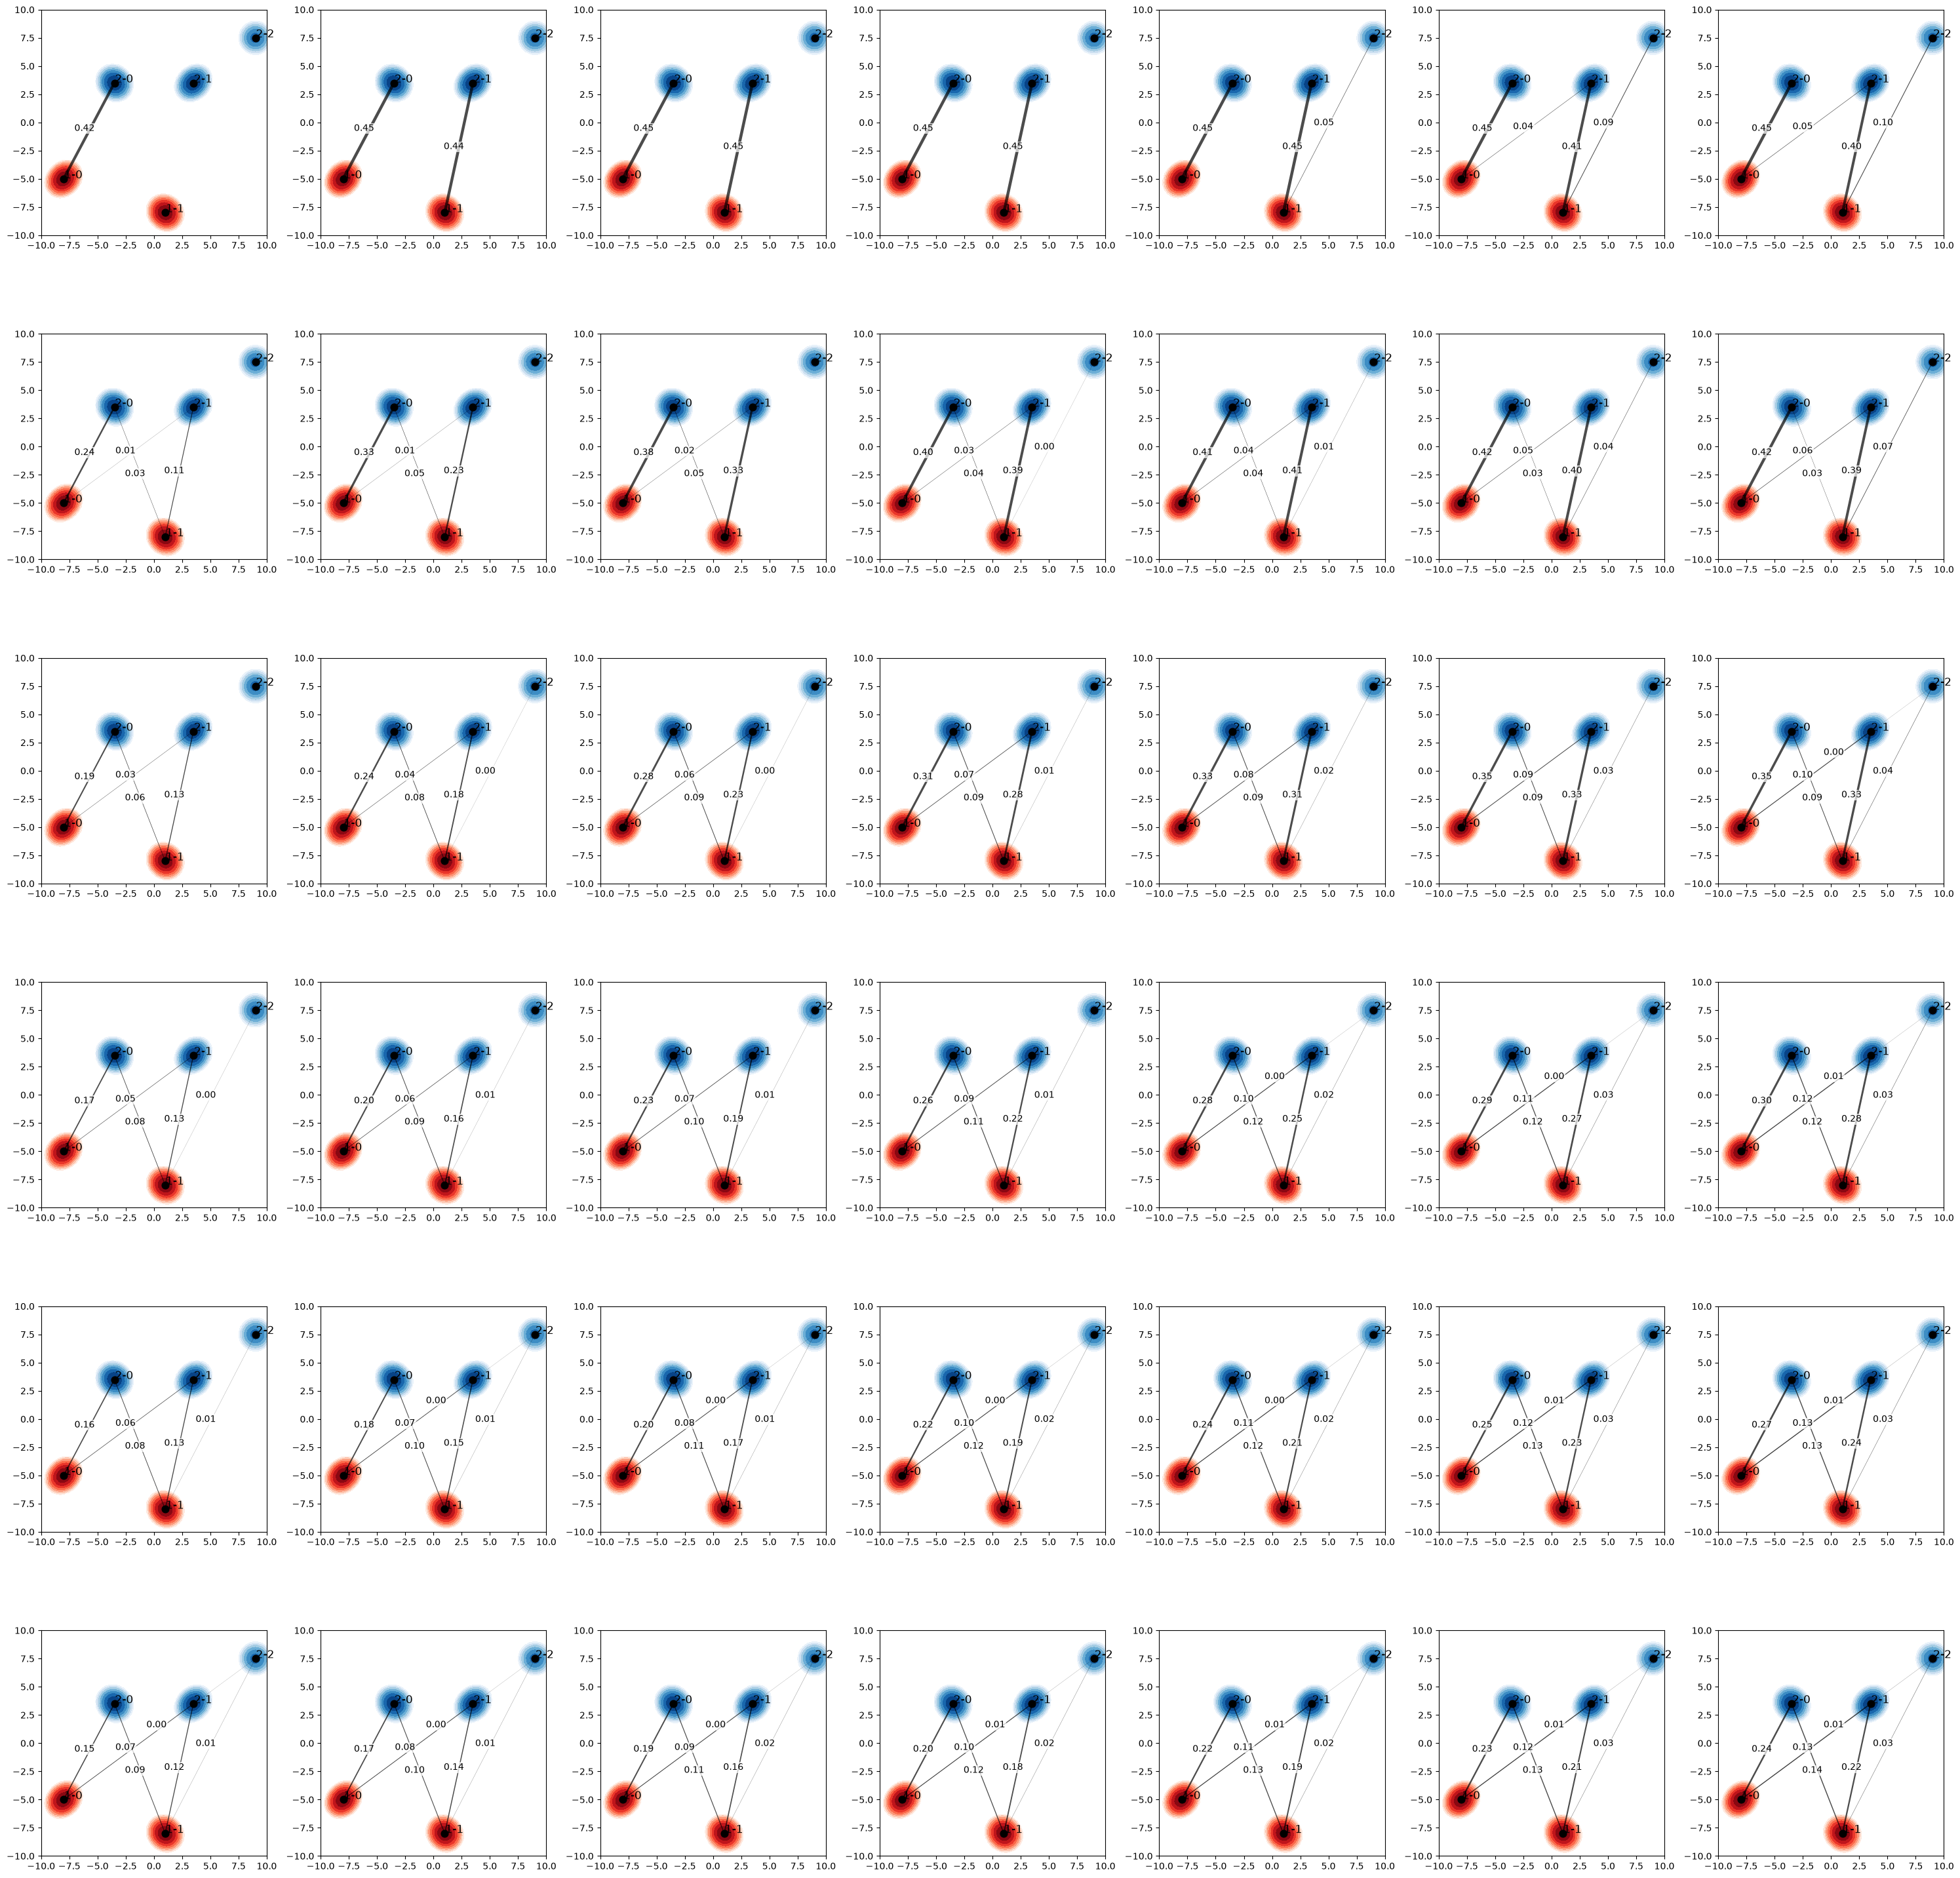

In [7]:
Lambda_list = np.arange(0.125, 0.5625, 0.0625)
reg_list = np.arange(0.01, 0.31, 0.05)
print("C1=", C1)
print("C2=", C2)
k = 2 * max(np.max(C1), np.max(C2))
cost1 = C1 / k
cost2 = C2 / k
M_1 = gaussian_W(Gmm_1, Gmm_2) / np.max(gaussian_W(Gmm_1, Gmm_2))
fig, axes = plt.subplots(
    len(reg_list), len(Lambda_list), figsize=(30, 30)
)  # 6 x 6 = 36 plots

for row, reg in enumerate(reg_list):
    for col, Lambda in enumerate(Lambda_list):
        ax = axes[row, col]
        plt.sca(ax)

        # ----------------------------------------
        # 3. draw GMMs
        # ----------------------------------------
        display_gmm(
            [Gmm_1.K, Gmm_1.weights, Gmm_1.comp_mean, Gmm_1.comp_cov],
            n=100,
            ax=-10,
            bx=10,
            ay=-10,
            by=10,
            cmap="Reds",
        )
        display_gmm(
            [Gmm_2.K, Gmm_2.weights, Gmm_2.comp_mean, Gmm_2.comp_cov],
            n=100,
            ax=-10,
            bx=10,
            ay=-10,
            by=10,
            cmap="Blues",
        )

        # ----------------------------------------
        # 2. entropic partial-W
        # ----------------------------------------
        R = entropic_partial_ot(
            a=Gmm_1.weights,
            b=Gmm_2.weights,
            M=M,
            Lambda=Lambda,
            reg=reg,
            numItermax=1000,
            stopThr=1e-9,
            remove_dummy=True,
        )
        mass_partial = np.sum(R)
        # print("Lambda= ", Lambda)
        print("mass_partial = ", mass_partial)
        # print("res = ", res)

        print("eplan = ", R)
        # print("error =", np.sum(np.abs(R - res)))

        # ----------------------------------------
        # safety check
        # ----------------------------------------
        if not isinstance(R, np.ndarray) or R.ndim != 2:
            print("R is not a 2D ndarray")
            ax.set_title(f"Lambda={Lambda}, reg={reg:.2f}\n(no coupling)", fontsize=12)
            ax.axis("equal")
            continue

        max_val = np.max(R)
        if max_val < 1e-15:
            max_val = 1e-15

        eps = 2.0 * 1e-3

        # ----------------------------------------
        # 4. centers
        # ----------------------------------------
        for i, (x, y) in enumerate(Gmm_1.comp_mean):
            ax.scatter(x, y, c="black", s=60)
            ax.text(x + 0.05, y + 0.05, f"1-{i}", color="black", fontsize=12)

        for j, (x, y) in enumerate(Gmm_2.comp_mean):
            ax.scatter(x, y, c="black", s=60)
            ax.text(x + 0.05, y + 0.05, f"2-{j}", color="black", fontsize=12)

        # ----------------------------------------
        # 5. coupling lines
        # ----------------------------------------
        for i in range(Gmm_1.K):
            for j in range(Gmm_2.K):
                w = R[i, j]
                if w < eps:
                    continue

                p1 = Gmm_1.comp_mean[i]
                p2 = Gmm_2.comp_mean[j]

                lw = 0.1 + 7 * (w)

                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], c="k", linewidth=lw, alpha=0.7)

                # ----------------------------
                # ★ 線分の中点にラベルを置く ★
                # ----------------------------
                # 線分方向
                vx = p2[0] - p1[0]
                vy = p2[1] - p1[1]
                # 直交方向
                nx = -vy
                ny = vx
                norm = np.sqrt(nx * nx + ny * ny) + 1e-12
                nx /= norm
                ny /= norm

                # オフセット量（調整可能）
                offset = 0.45

                # 中点 + オフセット
                mx = (p1[0] + p2[0]) / 2 + offset * nx
                my = (p1[1] + p2[1]) / 2 + offset * ny
                ax.text(
                    mx,
                    my,
                    f"{w:.2f}",
                    fontsize=10,
                    color="black",
                    ha="center",
                    va="center",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.0),
                )

plt.tight_layout()
plt.savefig("fig_lambda_epsilon_sweep.eps", format="eps")  # EPSとして保存
plt.show()

C1= [[4.44089210e-16 9.00090745e+01]
 [9.00090745e+01 0.00000000e+00]]
C2= [[0.00000000e+00 4.90090745e+01 1.72251003e+02]
 [4.90090745e+01 4.44089210e-16 4.62540511e+01]
 [1.72251003e+02 4.62540511e+01 0.00000000e+00]]
(Lambda, reg)=(0.100, 0.010)
eplan=
 [[1.91502925e-01 3.97630883e-12 2.90720833e-36]
 [4.36967325e-07 1.76134564e-05 2.66941808e-22]]
(Lambda, reg)=(0.200, 0.010)
eplan=
 [[4.49999316e-01 1.60760618e-07 4.87065594e-29]
 [6.47298145e-07 4.48913955e-01 2.81933611e-15]]
(Lambda, reg)=(0.300, 0.010)
eplan=
 [[4.49999366e-01 1.64653477e-07 2.36018388e-20]
 [6.33523049e-07 4.49999835e-01 1.33709803e-06]]
(Lambda, reg)=(0.400, 0.010)
eplan=
 [[4.50000000e-01 9.52859586e-04 5.21503814e-12]
 [1.09240734e-10 4.49047140e-01 5.09444031e-02]]
(Lambda, reg)=(0.500, 0.010)
eplan=
 [[4.49752549e-01 4.96929874e-02 5.98895319e-10]
 [1.86513047e-12 4.00056766e-01 9.99432328e-02]]
(Lambda, reg)=(0.100, 0.260)
eplan=
 [[0.14402434 0.06626158 0.00273574]
 [0.08592027 0.1173655  0.00926318]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


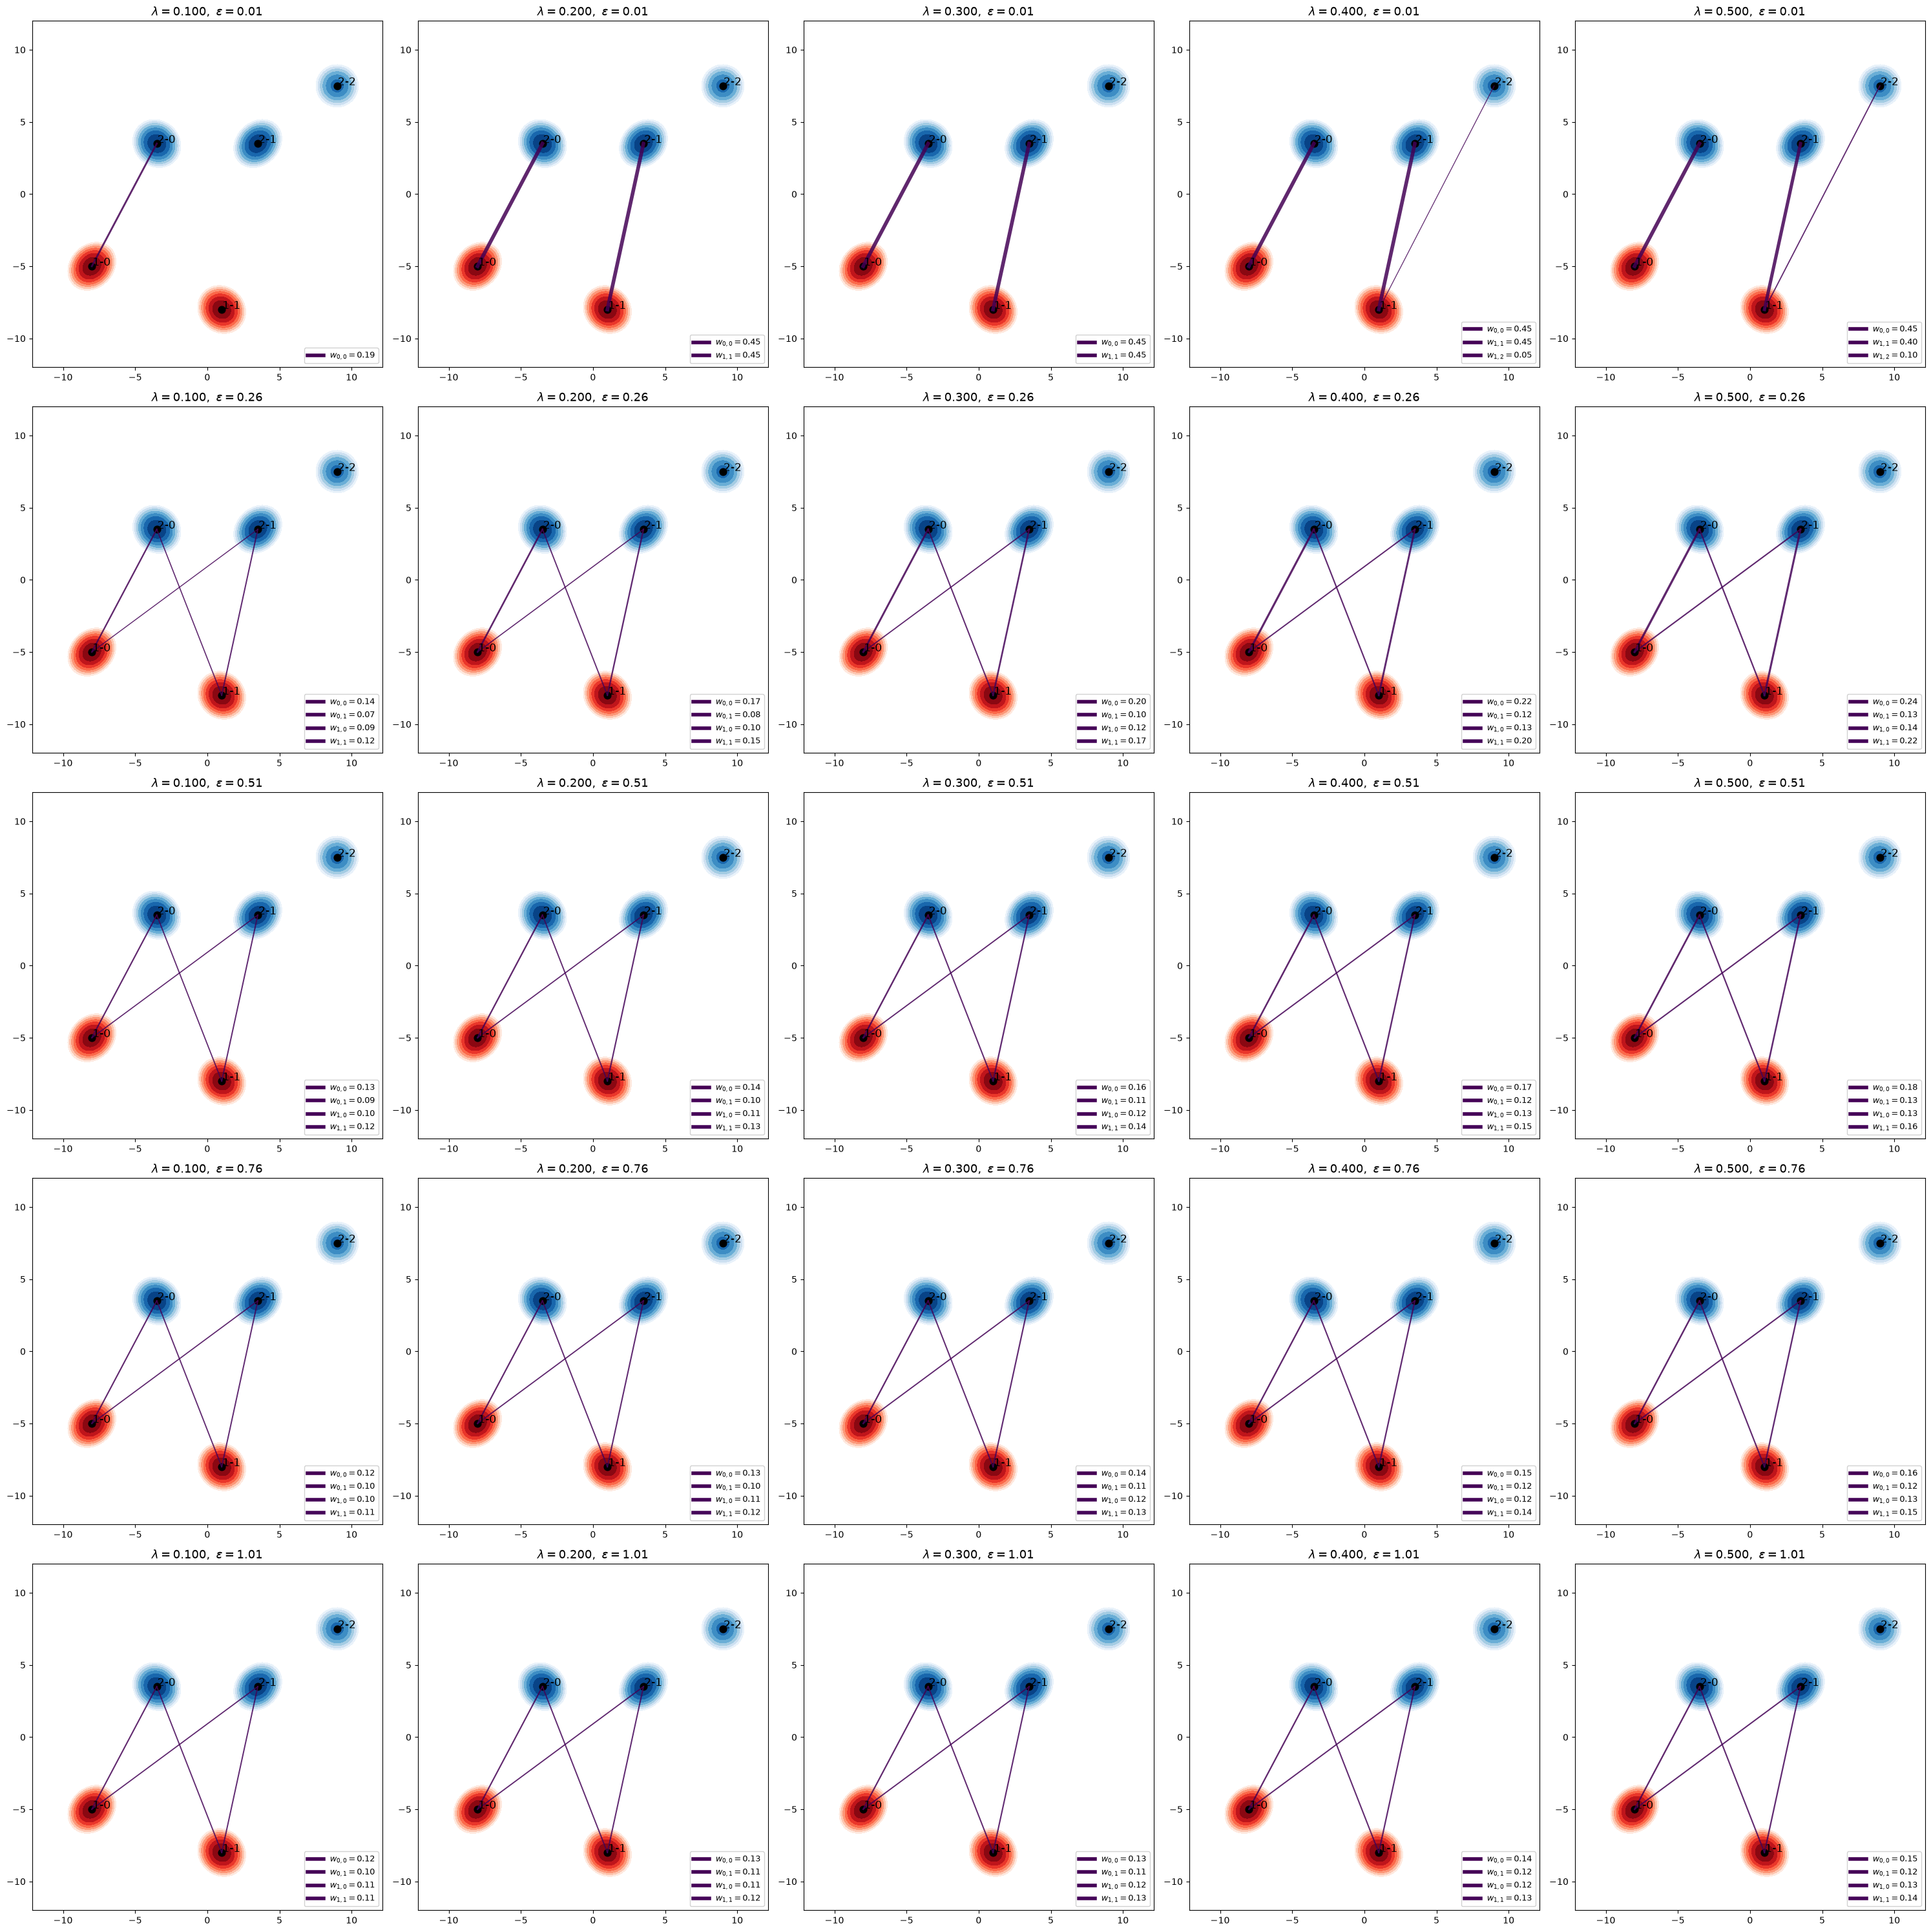

In [8]:
# ----------------------------
# parameters
# ----------------------------
Lambda_list = np.arange(0.1, 0.5625, 0.1)
reg_list = np.arange(0.01, 1.15, 0.25)

print("C1=", C1)
print("C2=", C2)

k = 2 * max(np.max(C1), np.max(C2))
cost1 = C1 / k
cost2 = C2 / k

M = gaussian_W(Gmm_1, Gmm_2)
M = M / np.max(M)

fig, axes = plt.subplots(len(reg_list), len(Lambda_list), figsize=(30, 30))

# ============================
# main loop
# ============================
for row, reg in enumerate(reg_list):
    for col, Lambda in enumerate(Lambda_list):
        ax = axes[row, col]
        plt.sca(ax)

        # ----------------------------------------
        # 1. draw GMMs
        # ----------------------------------------
        display_gmm(
            [Gmm_1.K, Gmm_1.weights, Gmm_1.comp_mean, Gmm_1.comp_cov],
            n=300,
            ax=-12,
            bx=12,
            ay=-12,
            by=12,
            cmap="Reds",
        )
        display_gmm(
            [Gmm_2.K, Gmm_2.weights, Gmm_2.comp_mean, Gmm_2.comp_cov],
            n=300,
            ax=-12,
            bx=12,
            ay=-12,
            by=12,
            cmap="Blues",
        )

        # ----------------------------------------
        # 2. entropic partial OT
        # ----------------------------------------
        R = entropic_partial_ot(
            a=Gmm_1.weights,
            b=Gmm_2.weights,
            M=M,
            Lambda=Lambda,
            reg=reg,
            numItermax=1000,
            stopThr=1e-9,
            remove_dummy=True,
        )

        print(f"(Lambda, reg)=({Lambda:.3f}, {reg:.3f})")
        print("eplan=\n", R)

        # ----------------------------------------
        # safety check
        # ----------------------------------------
        if not isinstance(R, np.ndarray) or R.ndim != 2:
            ax.set_title(f"Lambda={Lambda}, reg={reg:.2f}\n(no coupling)", fontsize=12)
            ax.axis("equal")
            continue

        eps = 5.0e-2

        # ----------------------------------------
        # 3. centers
        # ----------------------------------------
        for i, (x, y) in enumerate(Gmm_1.comp_mean):
            ax.scatter(x, y, c="black", s=60)
            ax.text(x + 0.05, y + 0.05, f"1-{i}", color="black", fontsize=12)

        for j, (x, y) in enumerate(Gmm_2.comp_mean):
            ax.scatter(x, y, c="black", s=60)
            ax.text(x + 0.05, y + 0.05, f"2-{j}", color="black", fontsize=12)

        # ----------------------------------------
        # 4. collect active couplings
        # ----------------------------------------
        pairs = [
            (i, j) for i in range(Gmm_1.K) for j in range(Gmm_2.K) if R[i, j] >= eps
        ]

        if len(pairs) == 0:
            ax.set_title(
                f"Lambda={Lambda}, reg={reg:.2f}\n(no active coupling)", fontsize=12
            )
            ax.axis("equal")
            continue

        # ----------------------------------------
        # 5. assign colors
        # ----------------------------------------
        cmap = plt.get_cmap("viridis")
        color_dict = {(i, j): cmap(k) for k, (i, j) in enumerate(pairs)}

        # ----------------------------------------
        # 6. draw coupling lines (NO labels)
        # ----------------------------------------
        for i, j in pairs:
            w = R[i, j]
            p1 = Gmm_1.comp_mean[i]
            p2 = Gmm_2.comp_mean[j]

            lw = 0.5 + 8.0 * w

            ax.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                linewidth=lw,
                color=color_dict[(i, j)],
                alpha=0.85,
            )

        # ----------------------------------------
        # 7. legend (color ↔ w_ij)
        # ----------------------------------------
        legend_elements = []
        for i, j in pairs:
            w = R[i, j]
            legend_elements.append(
                Line2D(
                    [0],
                    [0],
                    color=color_dict[(i, j)],
                    lw=4,
                    label=rf"$w_{{{i},{j}}}={w:.2f}$",
                )
            )

        ax.legend(
            handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.9
        )

        ax.set_title(rf"$\lambda={Lambda:.3f},\ \varepsilon={reg:.2f}$", fontsize=13)
        ax.axis("equal")

# ============================
# finalize
# ============================
plt.tight_layout()
plt.savefig("fig_lambda_epsilon_sweep.eps", format="eps")
plt.show()